In [1]:
#---IMPORTS---
import torch
from torch import nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

In [2]:
#---CONFIGS---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
IMG_SIZE = 20
IMG_CHANNEL = 1
NOISE_DIM = 300
BATCH_SIZE = 22
EPOCHS = 2500
LR = 1e-4
FEATURE_D = 64
FEATURE_G = 64

cuda


In [3]:
#---DATASET---
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(size= (20,20)),
    transforms.ToTensor(),
    transforms.Normalize([0.5 for _ in range(IMG_CHANNEL)],[0.5 for _ in range(IMG_CHANNEL)])
    ])

dataset = datasets.ImageFolder(root= "photonic_images",
                               transform= transform)

loader = DataLoader(dataset=dataset,
                    batch_size= BATCH_SIZE,
                    shuffle= True)

In [4]:
print(f"Length of dataset: {len(dataset)}")
print(f"Number of batches: {len(loader)}")
imgs, labels = next(iter(loader))
print(f"Batch Shape: {imgs.shape}")

Length of dataset: 22
Number of batches: 1
Batch Shape: torch.Size([22, 1, 20, 20])


In [5]:
#---MODELS---
class Discriminator(nn.Module):
    def __init__(self, IMG_CHANNEL, FEATURE_D):
        super().__init__()
        
        self. disc = nn.Sequential(
            nn.Conv2d(in_channels= IMG_CHANNEL, out_channels= FEATURE_D, kernel_size= 5, stride= 2, padding= 2),
            nn.LeakyReLU(0.3),
            nn.Dropout(0.3),

            self._block(in_channels= FEATURE_D, out_channels= FEATURE_D*2, kernel_size= 5, stride= 2, padding= 2),

            nn.Flatten(),
            nn.Linear(in_features= FEATURE_D*50, out_features= 1),
            )
    
    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.LeakyReLU(0.3),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        return self.disc(x)
    
class Generator(nn.Module):
    def __init__(self, NOISE_DIM, IMG_CHANNEL, FEATURE_G):
        super().__init__()
        self.FEATURE_G = FEATURE_G

        self.linear = nn.Linear(in_features= NOISE_DIM, out_features= FEATURE_G*100)
        self.batch_norm = nn.BatchNorm1d(FEATURE_G*100)
        self.leaky_relu = nn.LeakyReLU(0.3)

        self.gen = nn.Sequential(
            nn.ConvTranspose2d(in_channels= FEATURE_G*4, out_channels= FEATURE_G*2, kernel_size= 5, stride= 1, padding= 2),
            nn.BatchNorm2d(FEATURE_G*2),
            nn.LeakyReLU(0.3),

            self._block(in_channels= FEATURE_G*2, out_channels= FEATURE_G, kernel_size= 5, stride= 2, padding= 2, out_padding= 1),

            nn.ConvTranspose2d(in_channels= FEATURE_G, out_channels= IMG_CHANNEL, kernel_size= 5, stride= 2, padding= 2, output_padding= 1),
            nn.Tanh()
            )
                
    def _block(self, in_channels, out_channels, kernel_size, stride, padding, out_padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, out_padding),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.3)
            )

    def forward(self, x):
        x = self.linear(x)
        x = self.batch_norm(x)
        x = self.leaky_relu(x)
        x = x.reshape(-1,self.FEATURE_G*4,5,5)
        return self.gen(x)


def initializing_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
            if hasattr(m, 'out_channels') and m.out_channels == 1:
                nn.init.xavier_uniform_(m.weight.data)
            elif hasattr(m, 'out_features') and m.out_features == 1:
                nn.init.xavier_uniform_(m.weight.data)
            else:
                nn.init.kaiming_normal_(m.weight.data, mode='fan_out', nonlinearity='leaky_relu')


def test():

    img_channel, feature_d, H, W = 1, 8, 20, 20
    noise_dim = 300

    real = torch.randn(1,img_channel,H,W)
    noise = torch.randn(2,noise_dim)

    disc = Discriminator(img_channel, feature_d)
    assert disc(real).shape == (1, 1), "Discriminator test failed"

    gen = Generator(NOISE_DIM= noise_dim, IMG_CHANNEL=img_channel, FEATURE_G= 8)
    assert gen(noise).shape == (2, img_channel, 20, 20), "Generator test failed"

    print("Success, tests passed!")
    disc(real).shape
    gen(noise).shape

test()




Success, tests passed!


In [6]:
#---TRAINING_SETUP---
disc = Discriminator(IMG_CHANNEL= IMG_CHANNEL, FEATURE_D= FEATURE_D).to(device)
initializing_weights(disc)

gen = Generator(NOISE_DIM= NOISE_DIM, IMG_CHANNEL= IMG_CHANNEL, FEATURE_G= FEATURE_G).to(device)
initializing_weights(gen)

disc_optim = optim.Adam(params= disc.parameters(), lr= LR)
gen_optim = optim.Adam(params= gen.parameters(), lr= LR)

loss_fn = nn.BCEWithLogitsLoss()

FIXED_NOISE = torch.randn(BATCH_SIZE, NOISE_DIM).to(device)

writer_fake = SummaryWriter(log_dir= "logs/fake")
writer_real = SummaryWriter(log_dir= "logs/real")

step = 0

In [7]:
real, _ = next(iter(loader))
real = real.to(device)
print(f"Img Shape: {real.shape}")

noise = torch.randn(BATCH_SIZE, NOISE_DIM).to(device)
print(f"Noise Shape: {noise.shape}")

fake = gen(noise)

real_D = disc(real).reshape(-1)
print(f"real_D Shape: {real_D.shape}")

fake_D = disc(fake).reshape(-1)
print(f"fake_D Shape: {fake_D.shape}")


Img Shape: torch.Size([22, 1, 20, 20])
Noise Shape: torch.Size([22, 300])
real_D Shape: torch.Size([22])
fake_D Shape: torch.Size([22])


In [8]:
for epoch in range(EPOCHS):
    for batch, (real, _) in enumerate(loader):

        real = real.to(device)
        noise = torch.randn(BATCH_SIZE, NOISE_DIM).to(device)
        fake = gen(noise)

    # Train Discriminator: max log(D(x)) + log(1 - D(G(z)))
        real_D = disc(real).reshape(-1)
        real_D_loss = loss_fn(real_D, torch.ones_like(real_D))

        fake_D = disc(fake.detach()).reshape(-1)
        fake_D_loss = loss_fn(fake_D, torch.zeros_like(fake_D))

        lossD = (real_D_loss + fake_D_loss) / 2

        disc_optim.zero_grad()

        lossD.backward()

        disc_optim.step()

    # Train Generator: max log(D(G(z)))
        output = disc(fake)
        lossG = loss_fn(output, torch.ones_like(output))

        gen_optim.zero_grad()

        lossG.backward()

        gen_optim.step()

    if epoch % 10 == 0:
            print(f"EPOCH: {epoch}/{EPOCHS} | LOSS_D: {lossD.item():.4f} | LOSS_G: {lossG.item():.4f}")
              
            with torch.no_grad():
                gen.eval()
                fake_display = gen(FIXED_NOISE).reshape(-1, 1, IMG_SIZE, IMG_SIZE)
                gen.train()
                real_display = real.reshape(-1, 1, IMG_SIZE, IMG_SIZE)
                img_grid_fake = torchvision.utils.make_grid(fake_display, normalize=True)
                img_grid_real = torchvision.utils.make_grid(real_display, normalize=True)
                
                writer_fake.add_image("Photonic Fake", img_grid_fake, global_step=step)
                writer_real.add_image("Photonic Real", img_grid_real, global_step=step)
                
                step += 1


EPOCH: 0/2500 | LOSS_D: 0.6885 | LOSS_G: 0.7288
EPOCH: 10/2500 | LOSS_D: 0.6676 | LOSS_G: 0.7253
EPOCH: 20/2500 | LOSS_D: 0.6787 | LOSS_G: 0.6590
EPOCH: 30/2500 | LOSS_D: 0.7445 | LOSS_G: 0.5693
EPOCH: 40/2500 | LOSS_D: 0.7849 | LOSS_G: 0.6012
EPOCH: 50/2500 | LOSS_D: 0.7115 | LOSS_G: 0.8052
EPOCH: 60/2500 | LOSS_D: 0.6336 | LOSS_G: 0.9660
EPOCH: 70/2500 | LOSS_D: 0.6034 | LOSS_G: 0.9398
EPOCH: 80/2500 | LOSS_D: 0.6568 | LOSS_G: 0.7459
EPOCH: 90/2500 | LOSS_D: 0.6987 | LOSS_G: 0.7461
EPOCH: 100/2500 | LOSS_D: 0.6253 | LOSS_G: 0.9428
EPOCH: 110/2500 | LOSS_D: 0.5702 | LOSS_G: 0.9968
EPOCH: 120/2500 | LOSS_D: 0.4762 | LOSS_G: 1.1634
EPOCH: 130/2500 | LOSS_D: 0.4448 | LOSS_G: 1.1836
EPOCH: 140/2500 | LOSS_D: 0.5428 | LOSS_G: 0.8452
EPOCH: 150/2500 | LOSS_D: 0.5064 | LOSS_G: 1.0916
EPOCH: 160/2500 | LOSS_D: 0.4360 | LOSS_G: 1.2439
EPOCH: 170/2500 | LOSS_D: 0.4920 | LOSS_G: 0.9529
EPOCH: 180/2500 | LOSS_D: 0.4297 | LOSS_G: 1.3162
EPOCH: 190/2500 | LOSS_D: 0.3725 | LOSS_G: 1.2760
EPOCH: 200/

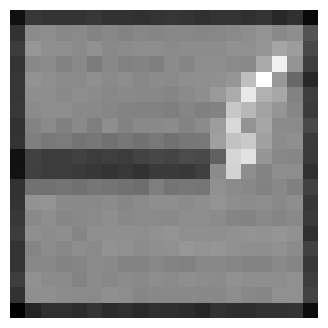

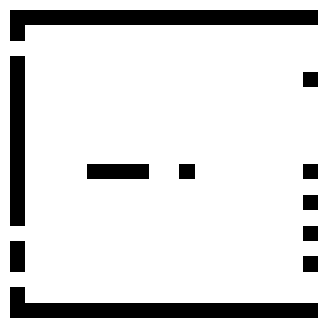

In [9]:
with torch.no_grad():
    gen.eval()
    single_noise = torch.randn(1, NOISE_DIM).to(device)
    single_img = gen(single_noise).squeeze().cpu()
    single_img = single_img * 0.5 + 0.5
    single_img = single_img.clamp(0, 1)
    gen.train()
    
    # Continuous
    plt.figure(figsize=(4, 4))
    plt.imshow(single_img, cmap="gray")
    plt.axis("off")
    plt.savefig("generated_photonic_continuous.png", bbox_inches="tight", dpi=150)
    plt.show()

    # Binary
    binary_img = (single_img > 0.5).float()
    plt.figure(figsize=(4, 4))
    plt.imshow(binary_img, cmap="gray")
    plt.axis("off")
    plt.savefig("generated_photonic_binary.png", bbox_inches="tight", dpi=150)
    plt.show()



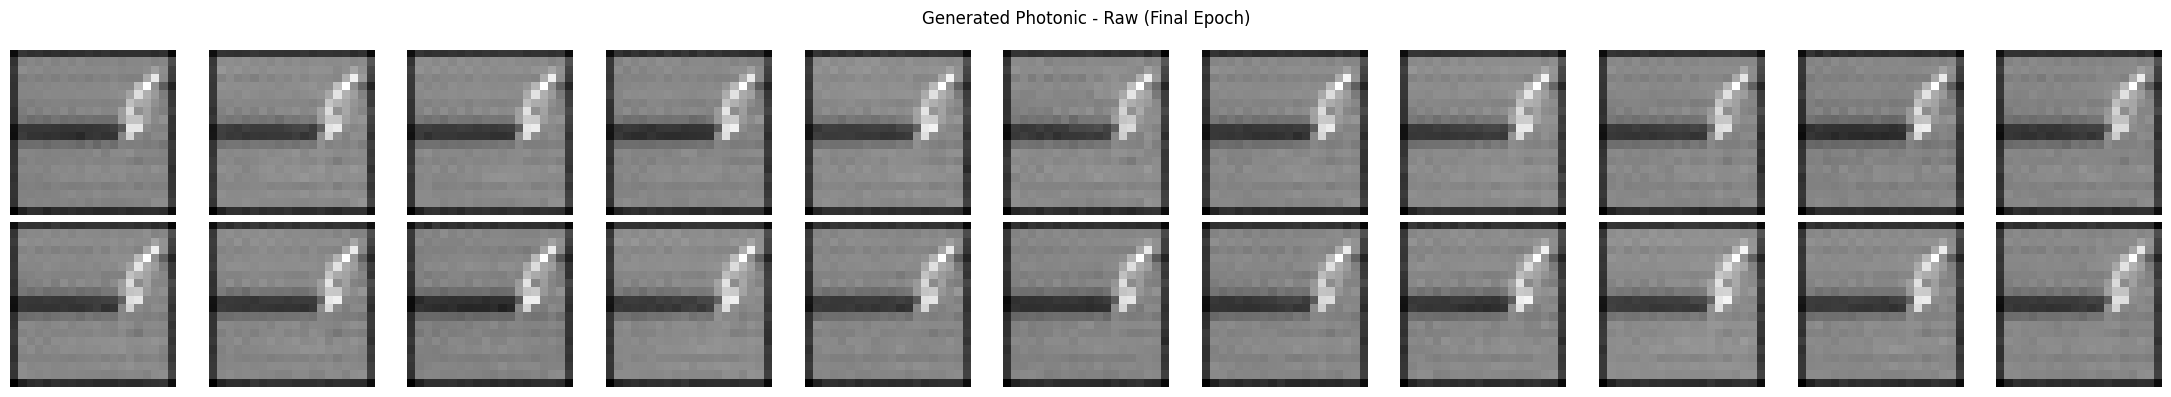

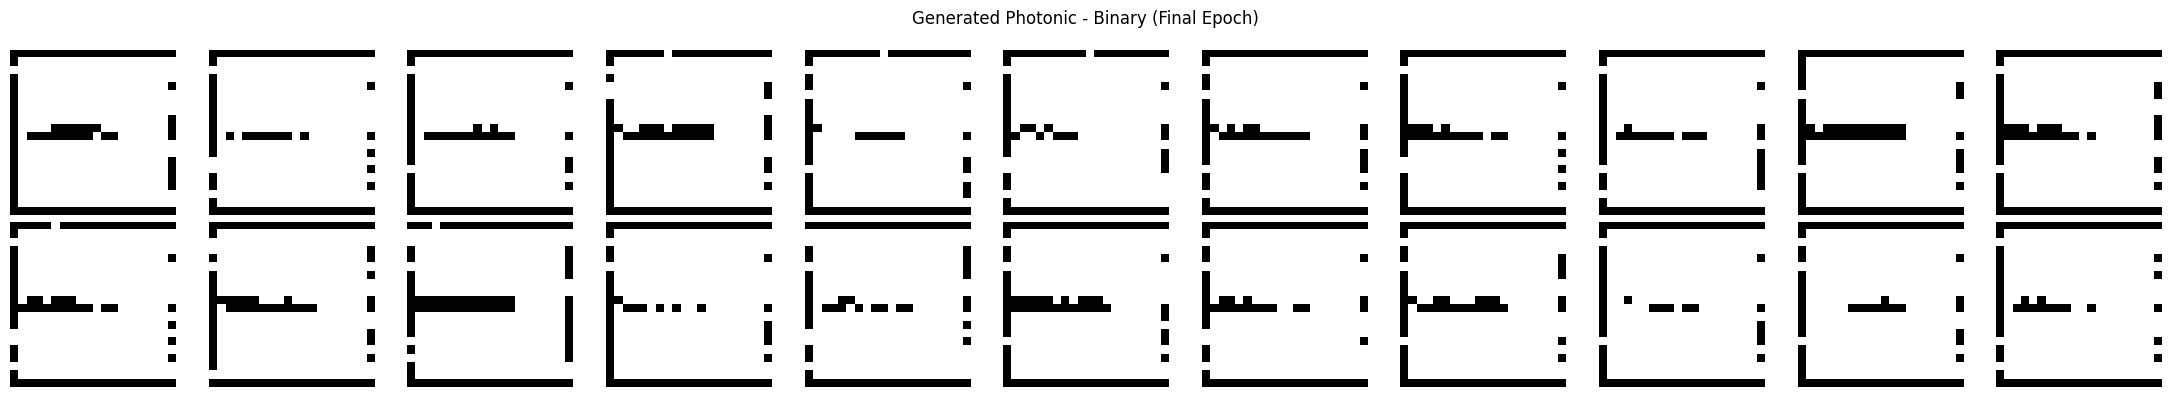

In [10]:
#---VISUALIZATION---
with torch.no_grad():
    gen.eval()
    sample = gen(FIXED_NOISE).reshape(-1, 1, IMG_SIZE, IMG_SIZE).cpu()
    gen.train()

sample_raw = sample * 0.5 + 0.5
sample_binary = (sample_raw > 0.5).float()

# Raw
fig, axes = plt.subplots(2, 11, figsize=(22, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_raw[i].squeeze(), cmap="gray")
    ax.axis("off")
plt.suptitle("Generated Photonic - Raw (Final Epoch)")
plt.tight_layout()
plt.show()

# Binary
fig, axes = plt.subplots(2, 11, figsize=(22, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_binary[i].squeeze(), cmap="gray")
    ax.axis("off")
plt.suptitle("Generated Photonic - Binary (Final Epoch)")
plt.tight_layout()
plt.show()